# 05 · Which assumptions matter most?
The full-size results are produced by `scripts/run_analysis.py`; this notebook reads them and reproduces a small version of each method.

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
pd.set_option("display.width", 160); pd.set_option("display.max_columns", 20)
from offshore_risk import load_config
cfg = load_config()
res = '../outputs/results/'
pd.read_csv(res + 'parameter_importance_summary.csv')

,parameter,eal_swing,rank_tornado,spearman_rho,abs_rho,rank_spearman,S1,rank_S1,mean_rank
0,bi_value_fraction,8.269805e+06,1.0,0.606059,0.606059,1.0,0.384443,1.0,1.000000
1,ptw_isolation_failure_prob,4.232000e+06,2.0,0.285388,0.285388,2.0,0.151080,2.0,2.000000
2,rel_flange_seal_rate,3.450996e+06,3.0,0.283951,0.283951,3.0,0.115541,3.0,3.000000
3,pipeline_rate_per_km_yr,3.259366e+06,6.0,0.251494,0.251494,4.0,0.074362,5.0,5.000000
4,rel_valve_rate,2.992564e+06,8.0,0.222358,0.222358,5.0,0.089882,4.0,5.666667
5,comp_repair_days,3.298557e+06,5.0,0.203855,0.203855,6.0,0.061300,6.0,5.666667
6,comp_weibull_scale_years,3.149018e+06,7.0,-0.196611,0.196611,7.0,0.048319,7.0,7.000000
7,weather_rate,3.333318e+06,4.0,0.160301,0.160301,8.0,0.042816,9.0,7.000000
8,pipeline_repair_days,1.085012e+06,12.0,0.124962,0.124962,13.0,0.041526,10.0,11.666667
9,comp_production_impact,1.504895e+06,11.0,0.087580,0.087580,18.0,0.046331,8.0,12.333333


In [2]:
tor = pd.read_csv(res + 'tornado.csv')
tor[['parameter', 'value_low', 'value_high', 'eal_low', 'eal_high', 'eal_swing', 'p99_swing']].head(10)

,parameter,value_low,value_high,eal_low,eal_high,eal_swing,p99_swing
0,bi_value_fraction,0.400000,0.677526,1.523564e+07,2.350544e+07,8.269805e+06,5.744602e+07
1,ptw_isolation_failure_prob,0.000211,0.004604,1.778384e+07,2.201584e+07,4.232000e+06,4.789353e+07
2,rel_flange_seal_rate,0.042488,0.235363,1.800751e+07,2.145851e+07,3.450996e+06,2.401592e+07
3,weather_rate,0.233088,0.686437,1.779167e+07,2.112499e+07,3.333318e+06,7.109320e+06
4,comp_repair_days,5.097618,11.225113,1.754222e+07,2.084078e+07,3.298557e+06,6.357598e+06
5,pipeline_rate_per_km_yr,0.000212,0.001177,1.805195e+07,2.131132e+07,3.259366e+06,9.319012e+07
6,comp_weibull_scale_years,3.000000,4.387628,2.081987e+07,1.767085e+07,3.149018e+06,4.892253e+06
7,rel_valve_rate,0.033990,0.188291,1.788250e+07,2.087506e+07,2.992564e+06,3.807718e+07
8,production_rate_factor,0.911237,1.050000,1.779192e+07,1.999626e+07,2.204342e+06,1.393048e+07
9,rel_corrosion_rate,0.021244,0.117682,1.874479e+07,2.042052e+07,1.675733e+06,1.686849e+07


In [3]:
pd.read_csv(res + 'rank_correlation_es99.csv').head(8)

,parameter,spearman_rho,abs_rho,p_value
0,bi_value_fraction,0.428574,0.428574,2.665007e-19
1,ptw_isolation_failure_prob,0.259587,0.259587,1.394003e-07
2,pipeline_repair_days,0.249997,0.249997,4.085452e-07
3,pipeline_rate_per_km_yr,0.204951,0.204951,3.625870e-05
4,rel_flange_seal_rate,0.200031,0.200031,5.604282e-05
5,rel_valve_rate,0.193869,0.193869,9.526846e-05
6,psv_pfd,0.138485,0.138485,5.530095e-03
7,dt_explosion_days,0.130029,0.130029,9.227809e-03


## Small live example (tornado on four parameters)

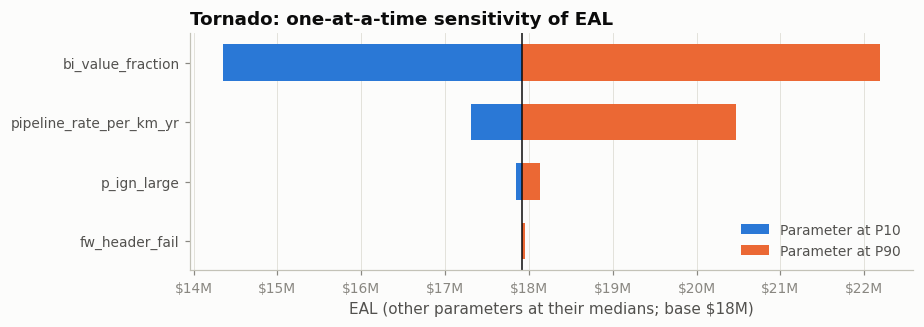

In [4]:
from offshore_risk.sensitivity.analysis import tornado
from offshore_risk.visualization import plots
small = tornado(cfg, n_years=5000, params=['bi_value_fraction', 'pipeline_rate_per_km_yr', 'p_ign_large', 'fw_header_fail'])
fig = plots.tornado(small, 'eal')

**Reading.** The single most influential assumption is economic: the value of a deferred barrel (`bi_value_fraction`). Engineering parameters that drive *frequent* losses (release cause rates, compressor life, repair times) dominate the EAL; for the tail, the pipeline failure rate and repair duration join the release cause rates at the top. Below the top parameter the ranking is noisy (rank-correlation sampling error ≈ ±0.05 with 400 worlds), so read ranks 2–8 as a group. Protection-system reliability parameters (firewater, deluge) barely move either metric at this asset's assumed fire frequency — they matter for safety and for a catastrophic tail that is dominated by a handful of simulated years.